In [1]:
import json, os
from pathlib import Path
import pandas as pd

def load_model_results_per_task(cache_dir, default_prompt=None):
    model_results = []

    cache_dir_path = Path(cache_dir)
    for model_cache_dir_path in cache_dir_path.iterdir():
        if model_cache_dir_path.is_dir():
    
        
            project_dirs = [x for x in model_cache_dir_path.iterdir() if x.is_dir()]
            for experiments_project_dir in project_dirs:
                 if experiments_project_dir.exists():
                    for experiment_dir_path in (experiments_project_dir / "experiments").iterdir():
                        if experiment_dir_path.is_dir():
                            # print(experiment_dir_path)
                            task_file_path = [x for x in experiment_dir_path.iterdir() if x.suffix == '.json' and x.stem != "model_meta"][0]
                            model_meta_path = experiment_dir_path / 'model_meta.json'
            
                            model_meta = json.load(open(model_meta_path, 'r'))
                            scores = json.load(open(task_file_path, 'r'))['scores']
        
                            for split, split_val in scores.items():
                                # print(model_meta['experiment_kwargs'])
                                parsed_result_dict = {
                                        "main_score": split_val[0]['main_score'],
                                        "task": task_file_path.stem,
                                        "model": model_cache_dir_path.stem
                                    }
                                
        
                                if task_file_path.stem in model_meta['experiment_kwargs']['prompts']:
                                    parsed_result_dict['prompt'] = model_meta['experiment_kwargs']['prompts'][task_file_path.stem]
                                else:
                                    parsed_result_dict['prompt'] = model_meta['experiment_kwargs']['prompts'][task_file_path.stem + "-query"]
        
                                parsed_result_dict['is_baseline'] = parsed_result_dict['prompt'] == default_prompt
                                model_results.append(parsed_result_dict)
                        
                            
    return model_results
                    

In [2]:
prompts_results = load_model_results_per_task(
    "../../data/cache_data_customassignment_human_as_well/mteb_cache/results/",
)

In [3]:
# rename models for consistency

for i in range(len(prompts_results)):
    prompts_results[i]['model'] = prompts_results[i]['model'].replace("__", "/")
    if prompts_results[i]['model'] == "Qwen/Qwen3-Embedding-0":
        prompts_results[i]['model'] = "Qwen/Qwen3-Embedding-0.6B"
    if prompts_results[i]['model'] == 'BAAI/bge-base-en-v1':
        prompts_results[i]['model'] = "BAAI/bge-base-en-v1.5"
    if prompts_results[i]['model'] == "BAAI/bge-large-en-v1":
        prompts_results[i]['model'] = "BAAI/bge-large-en-v1.5"
    if prompts_results[i]['model'] == "BAAI/bge-small-en-v1":
        prompts_results[i]['model'] = "BAAI/bge-small-en-v1.5"
    if prompts_results[i]['model'] == "KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2":
        prompts_results[i]['model'] = "KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5"




In [4]:
human_prompts = json.load(open("../../src/manual_prompts/y_prompts.json", 'r'))

In [5]:
human_prompts[0]

{'task': 'MIRACLRetrievalHardNegatives.v2',
 'task_description': 'retrieval',
 'generated_prompt': 'Encode the following query for retrieval:'}

In [6]:
human_prompts = [x['generated_prompt'] for x in human_prompts]

In [7]:
df = pd.DataFrame(prompts_results)

In [8]:
df['is_human'] = df['prompt'].apply(lambda x: x in human_prompts)

In [9]:
df = df[df['model'].isin([
    "BAAI/bge-base-en-v1.5", "BAAI/bge-small-en-v1.5", "BAAI/bge-large-en-v1.5"
])]

In [10]:
df['is_human'].value_counts()

is_human
False    576
True     360
Name: count, dtype: int64

In [11]:
df.head().to_clipboard()

In [44]:
import mteb

cache = mteb.ResultCache()
# cache.download_from_remote(download_latest=True)

results = cache.load_results(
    models=df['model'].unique().tolist(),
    tasks=df['task'].unique().tolist(),
    include_remote=True, # default
)

baselines = []
for result in results:
    for task in result.task_results:
        baselines.append(
            {
                "main_score": task.main_score,
                "task": task.task_name,
                "model": result.model_name,
                "prompt": "default",
                "is_baseline": True
            }
        )

In [45]:
baselines[0]

{'main_score': 0.6514257083912395,
 'task': 'AmazonCounterfactualClassification',
 'model': 'BAAI/bge-large-en-v1.5',
 'prompt': 'default',
 'is_baseline': True}

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, ks_2samp, shapiro
from scipy.stats import permutation_test

def get_baseline_score(model, task, baselines):
    for x in baselines:
        if x['model'] == model and x['task'] == task:
            return x['main_score']
    

def plot_score_distributions(df, tasks, baselines, figsize_per_cell=(4, 3), alpha=0.05):
    """
    Create a grid of KDE plots comparing human vs machine-generated prompt scores
    across all task-model combinations. Transposed layout: tasks as rows, models as columns.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: main_score, task, model, is_human
    figsize_per_cell : tuple
        Size of each subplot (width, height)
    alpha : float
        Significance level for Mann-Whitney U test (default: 0.05)
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    results_df : pandas.DataFrame
        DataFrame with statistical test results for each combination
    """
    
    # Filter to only include task-model combinations that have human prompts
    combinations_with_human = df[df['is_human'] == True].groupby(['task', 'model']).size()
    valid_combinations = combinations_with_human[combinations_with_human > 0].index.tolist()
    
    print(f"Found {len(valid_combinations)} task-model combinations with human prompts")
    
    # Get unique tasks and models that have valid combinations
    valid_tasks = sorted(set([task for task, model in valid_combinations if task in tasks]))
    valid_models = sorted(set([model for task, model in valid_combinations if task in tasks]))
    
    # Transposed: tasks as rows, models as columns
    n_rows = len(valid_tasks)
    n_cols = len(valid_models)
    
    print(f"Creating grid: {n_rows} tasks × {n_cols} models")
    
    # Create figure with subplots
    fig, axes = plt.subplots(
        n_rows, n_cols, 
        figsize=(figsize_per_cell[0] * n_cols, figsize_per_cell[1] * n_rows),
        squeeze=False
    )
    
    # Get global min/max for consistent x-axis
    score_min = df['main_score'].min()
    score_max = df['main_score'].max()
    
    # Add some padding
    x_range = score_max - score_min
    xlim = (score_min - 0.05 * x_range, score_max + 0.05 * x_range)
    
    # Store statistical results
    stat_results = []
    
    # Plot each task-model combination (transposed)
    for i, task in enumerate(valid_tasks):
        for j, model in enumerate(valid_models):
            ax = axes[i, j]
            
            # Check if this combination is valid
            if (task, model) not in valid_combinations:
                ax.axis('off')
                continue
            
            # Filter data for this combination
            subset = df[(df['model'] == model) & (df['task'] == task)]
            
            if len(subset) > 0:
                # Separate human and machine prompts
                human_scores = subset[subset['is_human'] == True]['main_score'].values
                machine_scores = subset[subset['is_human'] == False]['main_score'].values
                
                # Plot KDE curves
                if len(human_scores) > 1:
                    sns.kdeplot(
                        data=human_scores, 
                        ax=ax, 
                        color='#3266ad',
                        fill=True,
                        alpha=0.3,
                        linewidth=2,
                        label=f'Human (n={len(human_scores)})'
                    )
                
                if len(machine_scores) > 1:
                    sns.kdeplot(
                        data=machine_scores, 
                        ax=ax, 
                        color='#d4537e',
                        fill=True,
                        alpha=0.3,
                        linewidth=2,
                        label=f'Machine (n={len(machine_scores)})'
                    )
                
                # Perform normality tests and choose appropriate statistical test
                if len(human_scores) > 2 and len(machine_scores) > 2:
                    # Shapiro-Wilk test for normality (works well for n=3 to n=5000)
                    # Need at least 3 samples for Shapiro-Wilk
                    human_normal = True
                    machine_normal = True

                    import numpy as np
                    def statistic(x, y, axis):
                        return np.median(x, axis=axis) - np.median(y, axis=axis)

                    res = permutation_test(
                        (human_scores, machine_scores), 
                                           statistic, vectorized=True,
                       n_resamples=10_000,
                                           # alternative='less'
                                          )
                    stat = res.statistic
                    p_value = res.pvalue
                    test_name = "Permutation Test (Median)"
                    is_different = "Different" if p_value < alpha else "Indistinguishable"
                    

                    
                    # if len(human_scores) >= 3:
                    #     _, human_p = shapiro(human_scores)
                    #     human_normal = human_p > 0.05  # Using alpha=0.05 for normality test
                    
                    # if len(machine_scores) >= 3:
                    #     _, machine_p = shapiro(machine_scores)
                    #     machine_normal = machine_p > 0.05
                    
                    # # Choose test based on normality
                    # if human_normal and machine_normal:
                    #     # Both normal -> use Kolmogorov-Smirnov test
                    #     stat, p_value = ks_2samp(human_scores, machine_scores)
                    #     test_name = "KS"
                    # else:
                    #     # At least one non-normal -> use Mann-Whitney U test
                    #     stat, p_value = mannwhitneyu(human_scores, machine_scores, alternative='two-sided')
                    #     test_name = "MW"
                    
                    # # Determine if distributions are significantly different
                    # is_different = "Different" if p_value < alpha else "Same"
                    
                    # Store results
                    stat_results.append({
                        'task': task,
                        'model': model,
                        'test_used': test_name,
                        'statistic': stat,
                        'p_value': p_value,
                        'significant': is_different,
                        'human_normal': human_normal if len(human_scores) >= 3 else None,
                        'machine_normal': machine_normal if len(machine_scores) >= 3 else None,
                        'n_human': len(human_scores),
                        'n_machine': len(machine_scores)
                    })
                    
                    # Add test name, p-value and significance to plot
                    test_text = f"{test_name}\np={p_value:.4f}\n{is_different}"
                    ax.text(0.02, 0.98, test_text, 
                           transform=ax.transAxes,
                           fontsize=7,
                           verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5, 
                                   edgecolor='gray', linewidth=0.5))


                    baseline_score = get_baseline_score(model, task, baselines)
                    ax.axvline(
                        baseline_score,
                        color="red",
                        linestyle="--",
                        linewidth=1
                    )
                    
                    # Add legend
                    ax.legend(fontsize=7, loc='upper right')
            
            # Set consistent x-axis
            ax.set_xlim(xlim)
            
            # Labels
            ax.set_ylabel('')
            
            # Show task name on leftmost column
            if j == 0:
                # Truncate long task names
                task_label = task if len(task) <= 30 else task[:27] + '...'
                ax.set_ylabel(task_label, fontsize=9, fontweight='bold')
            
            # Show model name on EVERY cell at the bottom
            # Extract model name (last part after /)
            model_label = model.split('/')[-1]
            ax.set_xlabel(model_label, fontsize=8, fontweight='bold')
            
            # Only show "Score" label on top row
            if i == 0:
                ax.set_title('Score', fontsize=9, pad=10)
            
            # Remove top and right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            # Style
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.2, linestyle='--')
    
    # Adjust layout

    # legend_elements = [
    #         Line2D([0], [0], color="red", lw=1, linestyle="--", label="Reported Baseline"),
    #     ]
    # fig.legend(
    #         handles=legend_elements,
    #         loc="upper center",
    #         bbox_to_anchor=(0.5, 0.98),
    #         ncol=2,
    #         frameon=False,
    #         fontsize=10
    #     )

    plt.tight_layout()

    # Create results DataFrame
    results_df = pd.DataFrame(stat_results)
    
    return fig, axes, results_df


# Example usage:
# if __name__ == "__main__":
    # Assuming you have a DataFrame 'df' with the required columns
    # df = pd.read_csv('your_data.csv')
    
    # Create the visualization
    # fig, axes, results_df = plot_score_distributions(df, figsize_per_cell=(4, 3), alpha=0.05)
    
    # Save the plot
    # plt.savefig('score_distributions.png', dpi=300, bbox_inches='tight')
    # plt.show()
    
    # View statistical test results
    # print("\nStatistical Test Results:")
    # print(results_df.to_string())
    
    # Save statistical results to CSV
    # results_df.to_csv('statistical_results.csv', index=False)
    
    # pass

In [75]:
df.task.unique()

array(['TweetSentimentClassification', 'MedrxivClusteringP2P.v2',
       'MasakhaNEWSClusteringS2S', 'STS22.v2',
       'AmazonCounterfactualClassification', 'FEVERHardNegatives',
       'StackExchangeClustering.v2', 'Touche2020Retrieval.v3',
       'ImdbClassification', 'MIRACLRetrievalHardNegatives.v2', 'STS15',
       'STS14'], dtype=object)

In [ ]:
tasks = [
    'TweetSentimentClassification', 'MedrxivClusteringP2P', 
    'STS22.v2',
       'AmazonCounterfactualClassification', 'FEVERHardNegatives',
        'StackExchangeClustering.v2', 'Touche2020Retrieval.v3',
       'ImdbClassification', 'MIRACLRetrievalHardNegatives.v2', 'STS15',
       'STS14']

Found 33 task-model combinations with human prompts
Creating grid: 6 tasks × 3 models


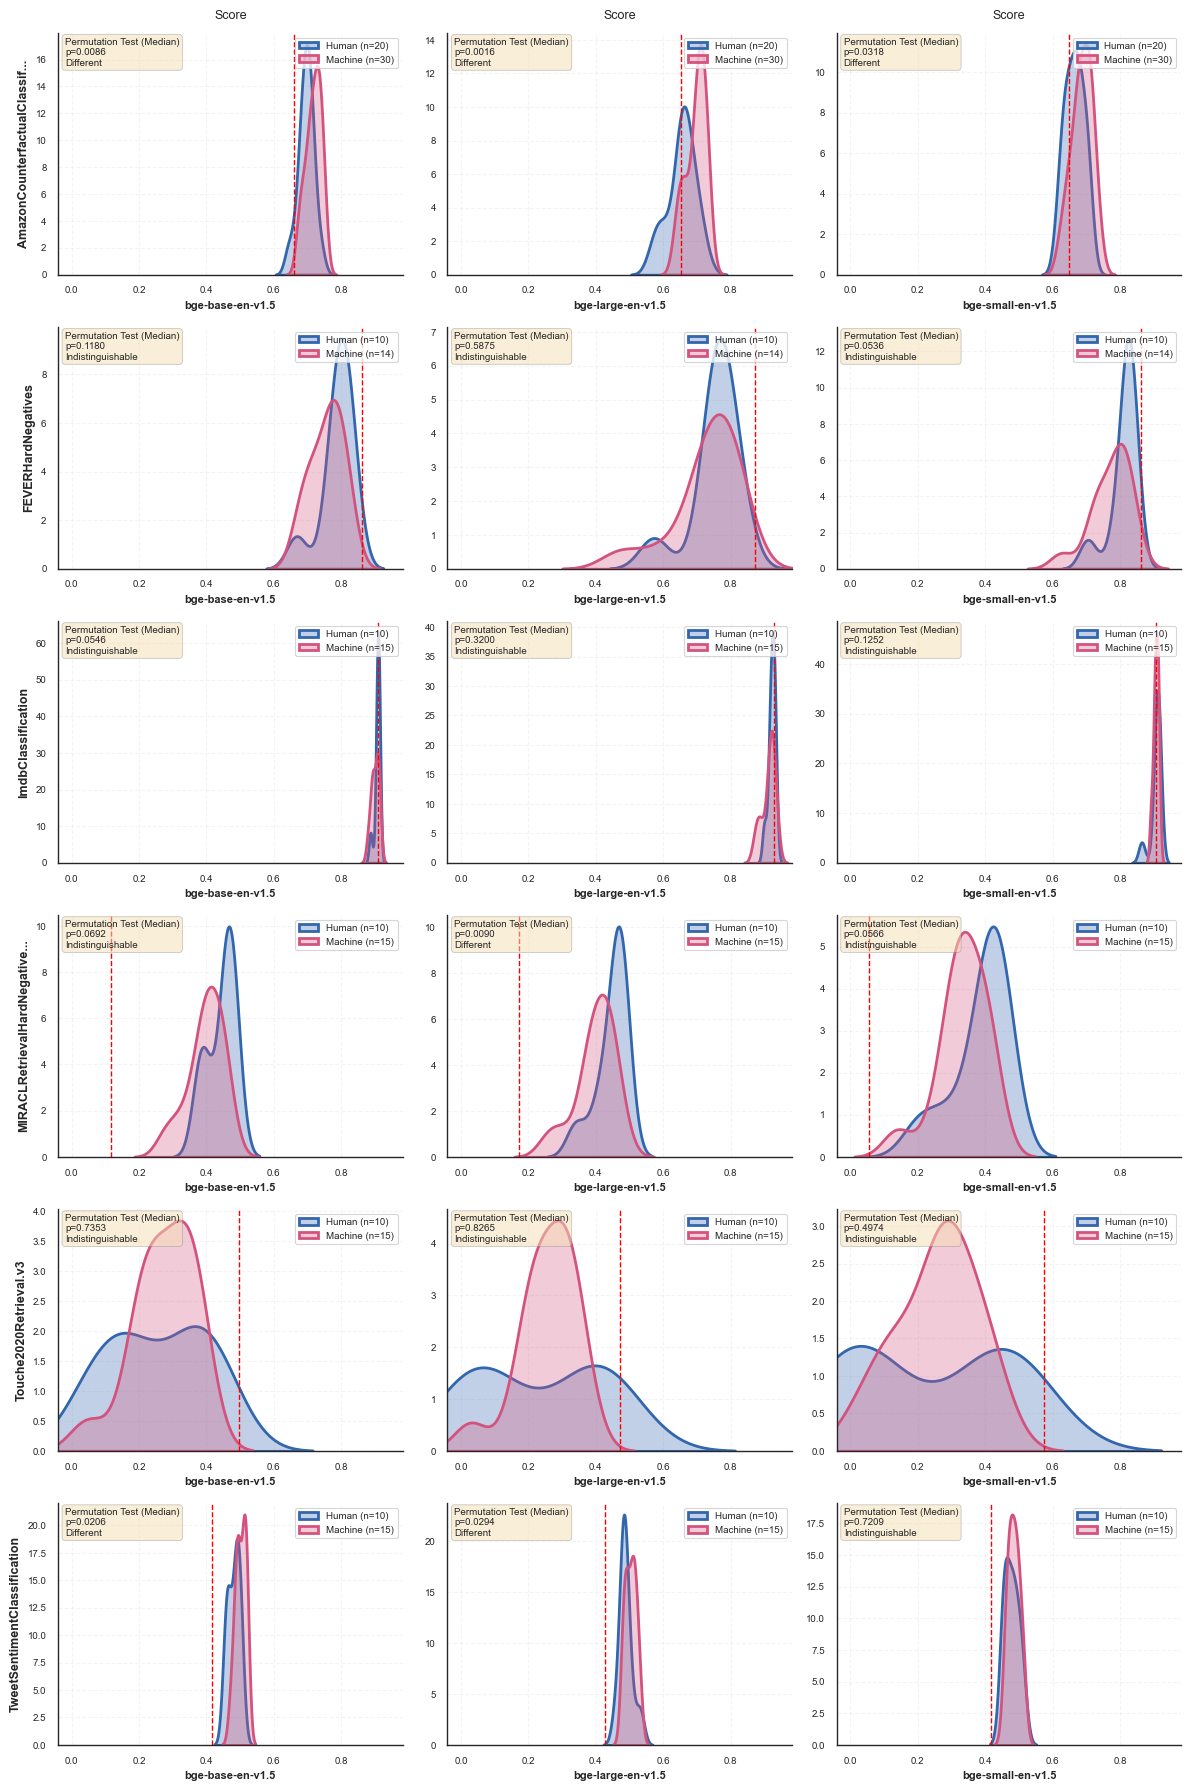

In [76]:
tasks = [
    'TweetSentimentClassification', 
       'AmazonCounterfactualClassification', 'FEVERHardNegatives',
        'Touche2020Retrieval.v3',
       'ImdbClassification', 'MIRACLRetrievalHardNegatives.v2']

fig, axes, results_df = plot_score_distributions(df, tasks, baselines, figsize_per_cell=(4, 3), alpha=0.05)
plt.savefig('plots/human_vs_machine_1.png', dpi=300, bbox_inches='tight')
plt.show()

Found 33 task-model combinations with human prompts
Creating grid: 5 tasks × 3 models


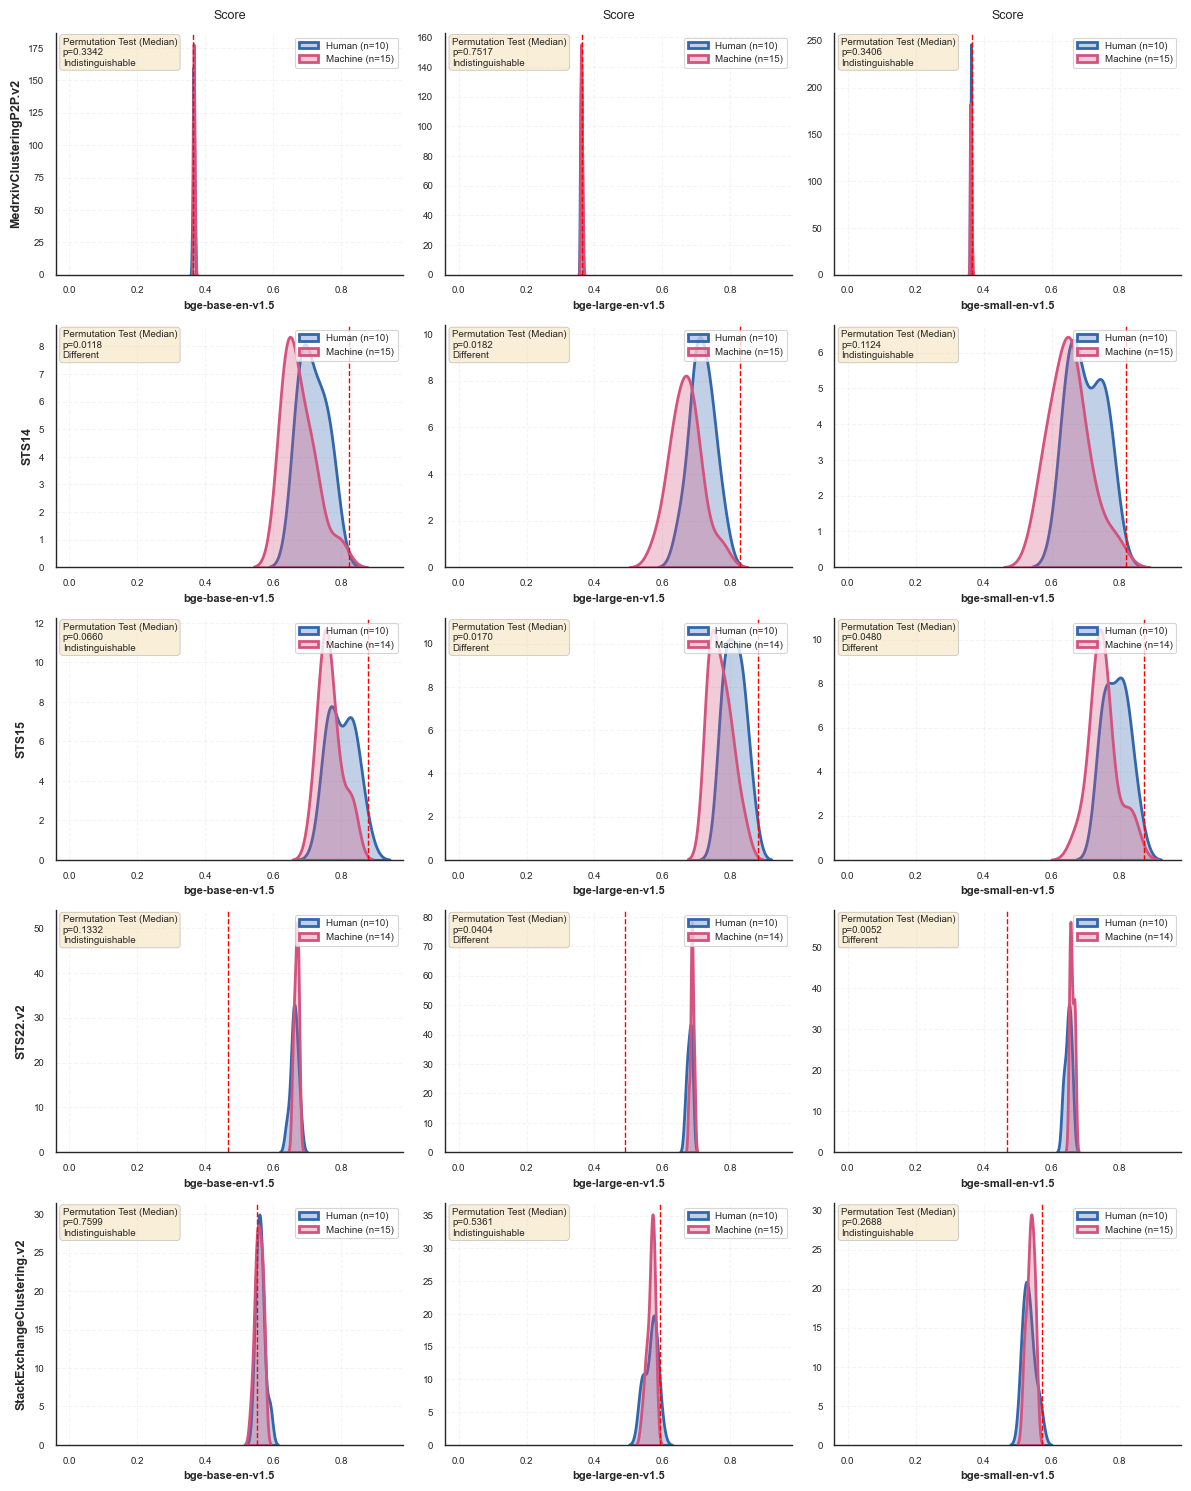

In [77]:
tasks = [
    'MedrxivClusteringP2P.v2', 'StackExchangeClustering.v2', 'STS15',
       'STS14', 'STS22.v2']

fig, axes, results_df = plot_score_distributions(df, tasks, baselines, figsize_per_cell=(4, 3), alpha=0.05)
plt.savefig('plots/human_vs_machine_2.png', dpi=300, bbox_inches='tight')
plt.show()